In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
diamonds = sns.load_dataset('diamonds')
diamonds.info()

In [28]:
ds = diamonds.sample(1000 , random_state=42)
ds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1388,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
50052,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
41645,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
42377,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
17244,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


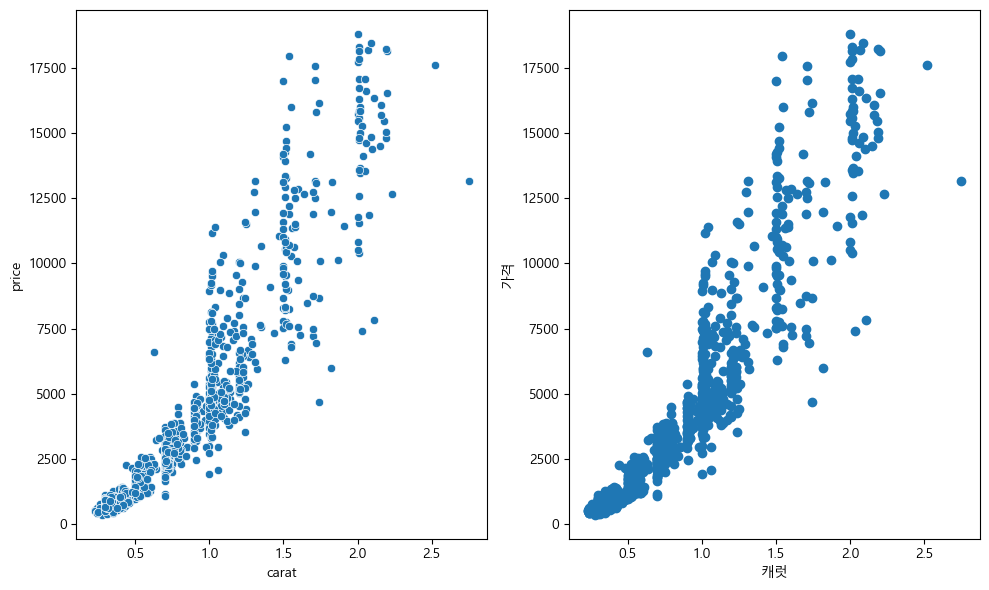

상관계수 : 0.922


In [37]:
fig,ax=plt.subplots(1,2,figsize=(10,6))
sns.scatterplot(data=ds , x = 'carat' , y='price' , ax=ax[0])
ax[1].scatter(ds['carat'] , ds['price'])
ax[1].set_xlabel('캐럿')
ax[1].set_ylabel('가격')

plt.tight_layout()
plt.show()

corr = diamonds['carat'].corr(diamonds['price'])
print(f'상관계수 : {corr:.3f}')

상관계수 : -1.000


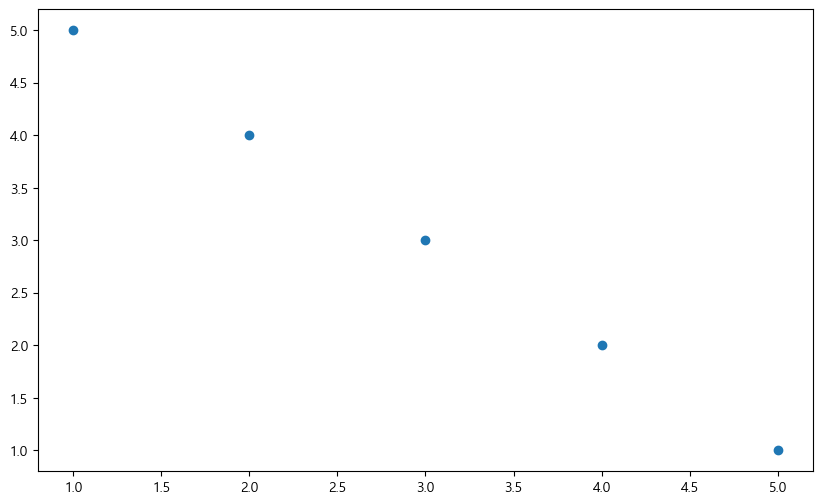

In [39]:
data = {
    'x' : [1,2,3,4,5] , 
    'y' : [5,4,3,2,1]
}
sample = pd.DataFrame(data)
fig,ax = plt.subplots(figsize=(10,6))
ax.scatter(sample['x'] , sample['y'])

corr = sample['x'].corr(sample['y'])
print(f'상관계수 : {corr:.3f}')

<Axes: xlabel='carat', ylabel='price'>

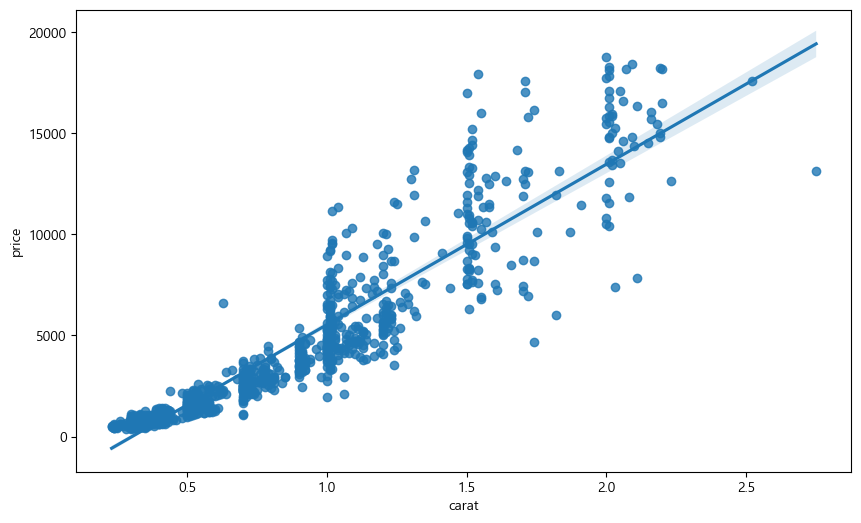

In [52]:
# Regplot : 회귀선

fig,ax = plt.subplots(figsize=(10,6))
sns.regplot(data=ds , x='carat' , y='price',ax=ax)

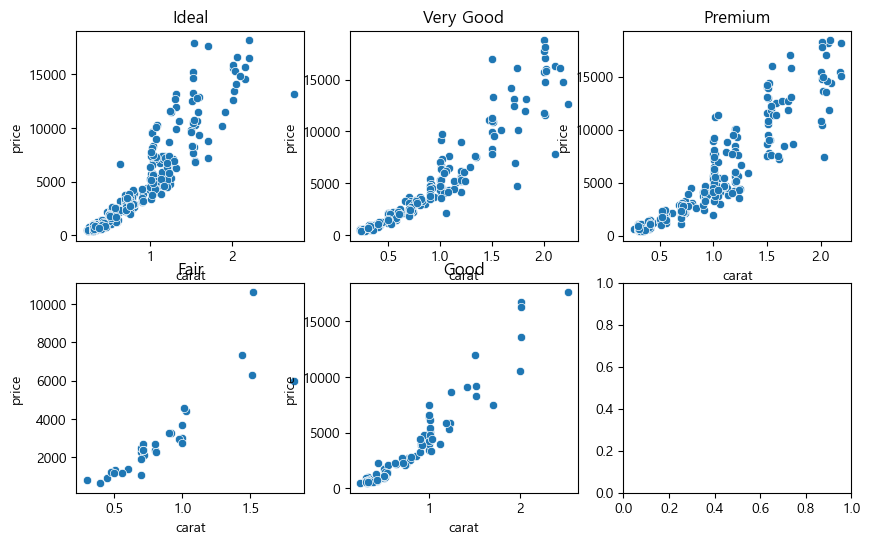

In [63]:
# 다이아몬드 등급에 따라서 가격패턴이 다른가?
fig,ax = plt.subplots(2,3,figsize=(10,6))
for idx , cut in enumerate(ds['cut'].unique()):
    sns.scatterplot(data = ds[ds['cut'] == cut] , x='carat' , y= 'price' , ax=ax[idx//3,idx%3])
    ax[idx//3,idx%3].set_title(cut)

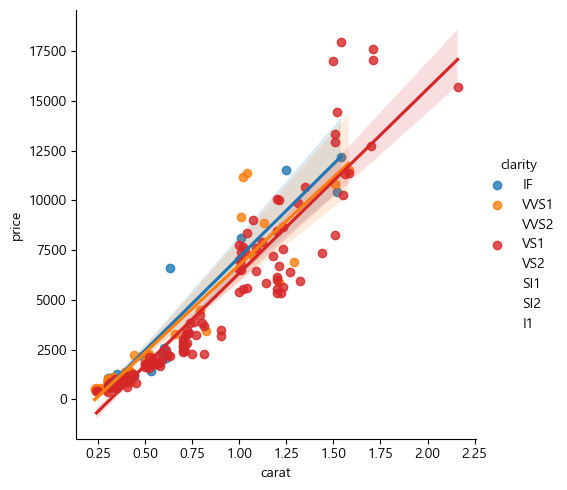

In [ ]:
filter = ds[ds['clarity'].isin(['IF', 'VVS1', 'VS1'])]
filter['clarity'].unique()
sns.lmplot(data=filter , x='carat' , y='price' , hue='clarity')

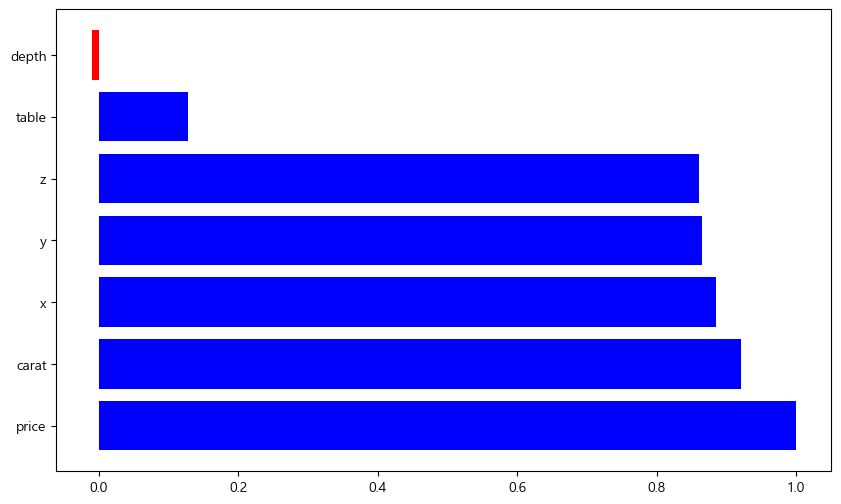

In [ ]:
numeric_cols = list(diamonds.describe().columns)
numeric_cols.remove('price')

col = diamonds[numeric_cols + ['price']].corr()['price'].sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(10,6))
colors = ['blue' if x > 0 else 'red' for x in col.values]
bars = ax.barh(col.index , col.values , color = colors)


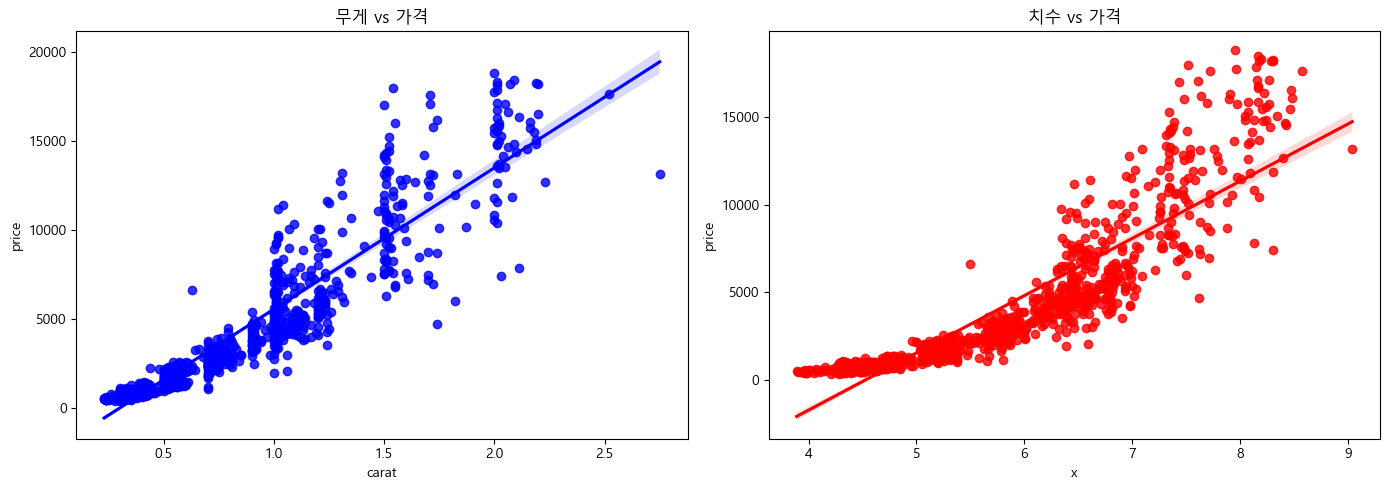

In [110]:
fig,ax = plt.subplots(1,2,figsize=(14,5))
sns.regplot(data=ds , x='carat' , y='price' , ax= ax[0] , color='blue')
ax[0].set_title('무게 vs 가격')
sns.regplot(data=ds , x = 'x' , y='price' , ax=ax[1] , color='red')
ax[1].set_title('치수 vs 가격')

plt.tight_layout()
plt.show()

In [116]:
ds[numeric_cols].corr()

,carat,depth,table,x,y,z
carat,1.000000,-0.078646,0.200590,0.980120,0.979933,0.978572
depth,-0.078646,1.000000,-0.344625,-0.127685,-0.127643,-0.009381
table,0.200590,-0.344625,1.000000,0.218992,0.212593,0.177378
x,0.980120,-0.127685,0.218992,1.000000,0.998434,0.992165
y,0.979933,-0.127643,0.212593,0.998434,1.000000,0.992446
z,0.978572,-0.009381,0.177378,0.992165,0.992446,1.000000
